<a href="https://colab.research.google.com/github/DanielHevdeli/hafifot-tiug/blob/annotator-agreement/notebooks/annotator-agreement.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [153]:
from huggingface_hub import notebook_login
notebook_login()

In [ ]:
from huggingface_hub import snapshot_download

# This downloads everything to a folder named 'c14_data'
snapshot_download(
    repo_id="js1699344/c14_articles",
    repo_type="dataset",
    local_dir="c14_data"
)

In [155]:
DATA_GROUP = "present"

In [156]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [157]:
data = pd.read_json(f'c14_data/data_split/{DATA_GROUP}/articles.jsonl', lines=True)
metadata = pd.read_csv(f'c14_data/data_split/{DATA_GROUP}/articles_metadata.csv')
metadata.head()

,id,date,wordsCount,author,archive_ids
0,691552,2022-09-15 10:22,739,דור אזרד,"63587,4329"
1,690427,2022-09-08 18:18,226,מערכת C14,"63587,4329"
2,690016,2022-09-07 21:44,422,מערכת C14,"63587,4329"
3,688340,2022-09-04 17:35,435,יצחק אבוחצירא,"63587,4329"
4,686593,2022-08-30 18:07,535,טל אזולאי אבידן,"63587,4329"


In [158]:
data.head()

,source,date,article_id,length,author,text
0,c14,2025-02-24 12:24:00,1128186,1176,רבקה שורק,פורום “בוחרים בחיים” של המשפחות השכולות הגיש ה...
1,c14,2025-02-24 12:17:00,1127982,1535,דין ברנדשטטר,שר התרבות והספורט מיקי זוהר הגיב הבוקר (שני) ל...
2,c14,2025-02-24 12:07:00,1128178,1337,יצחק אבוחצירא,"תלונה הוגשה ליועמ""שית גלי בהרב-מיארה בעניינו ש..."
3,c14,2025-02-24 11:46:00,1128035,858,רבקה שורק,"בעקבות נפילת נשיא סוריה לשעבר בשאר אל אסד, ולא..."
4,c14,2025-02-24 11:36:00,1128104,466,אור צעידי,קבוצת הכדורגל בני סכנין עלולה לעמוד לדין במידה...


In [159]:
print(f"Num of articles: {len(data)}")

Num of articles: 43536


In [160]:
ANNOTATORS = [
    'meta-llama/Llama-4-Scout-17B-16E-Instruct',
    'nvidia/nemotron-3-nano-30b-a3b-bf16',
    'openai/gpt-oss-120b'
]

In [161]:
annotations_dict = {
    annotator: pd.read_csv(f"c14_data/data_split/{DATA_GROUP}/annotations/{annotator}.csv")
    for annotator in ANNOTATORS
}

In [162]:
# convert the labels to numeric values for easier agreement computation
all_labels = set()
for annotator in ANNOTATORS:
    all_labels.update(annotations_dict[annotator]['label'].unique())
print(f"Unique labels across all annotators: {all_labels}")
label_to_id = {label: idx for idx, label in enumerate(sorted(all_labels))}
id_to_label = {idx: label for label, idx in label_to_id.items()}
print(f"Label to ID mapping: {label_to_id}")
print(f"ID to Label mapping: {id_to_label}")

for annotator in ANNOTATORS:
    annotations_dict[annotator]['label'] = annotations_dict[annotator]['label'].map(label_to_id)

# we have to order the rows by the same article_id for all annotators 
# to correctly compute agreement metrics (annotators might have different order of articles)
for annotator in ANNOTATORS:
    annotated_data = annotations_dict[annotator]
    annotated_data = annotated_data.sort_values(by='article_id')
    annotations_dict[annotator] = annotated_data.reset_index(drop=True)

Unique labels across all annotators: {'neutral', 'biased'}
Label to ID mapping: {'biased': 0, 'neutral': 1}
ID to Label mapping: {0: 'biased', 1: 'neutral'}


In [163]:
for annotator in ANNOTATORS:
    annotated_data = annotations_dict[annotator]
    print(f"{annotator}:")
    print(annotated_data.head())

meta-llama/Llama-4-Scout-17B-16E-Instruct:
  source  article_id  label
0    c14       60902      0
1    c14       60908      0
2    c14       60917      0
3    c14       60953      1
4    c14       60965      0
nvidia/nemotron-3-nano-30b-a3b-bf16:
  source  article_id  label
0    c14       60902      0
1    c14       60908      0
2    c14       60917      1
3    c14       60953      1
4    c14       60965      1
openai/gpt-oss-120b:
  source  article_id  label
0    c14       60902      0
1    c14       60908      0
2    c14       60917      0
3    c14       60953      1
4    c14       60965      1


In [164]:
for annotator in ANNOTATORS:
    annotated_data = annotations_dict[annotator]
    n_total = len(annotated_data)
    n_unknown = annotated_data[annotated_data['label'] == 'unknown'].shape[0]
    print(f"Num of Unknowns to {annotator}: {n_unknown}/{n_total} ({100 * (n_unknown / n_total)}%)")

Num of Unknowns to meta-llama/Llama-4-Scout-17B-16E-Instruct: 0/43536 (0.0%)
Num of Unknowns to nvidia/nemotron-3-nano-30b-a3b-bf16: 0/43536 (0.0%)
Num of Unknowns to openai/gpt-oss-120b: 0/43536 (0.0%)


In [165]:
from sklearn.metrics import cohen_kappa_score

In [166]:
agreement_matrix = pd.DataFrame(index=ANNOTATORS, columns=ANNOTATORS, dtype=float)

for i in range(len(ANNOTATORS)):
    for j in range(len(ANNOTATORS)):
        annotator_i = ANNOTATORS[i]
        annotator_j = ANNOTATORS[j]
        labels_i = annotations_dict[annotator_i]['label']
        labels_j = annotations_dict[annotator_j]['label']
        agreement_percentage = (labels_i == labels_j).mean()
        agreement_matrix.loc[annotator_i, annotator_j] = agreement_percentage

In [167]:
kappa_matrix = pd.DataFrame(index=ANNOTATORS, columns=ANNOTATORS, dtype=float)

for i in range(len(ANNOTATORS)):
    for j in range(len(ANNOTATORS)):
        annotator_i = ANNOTATORS[i]
        annotator_j = ANNOTATORS[j]
        labels_i = annotations_dict[annotator_i]['label']
        labels_j = annotations_dict[annotator_j]['label']
        kappa_score = cohen_kappa_score(labels_i, labels_j)
        kappa_matrix.loc[annotator_i, annotator_j] = kappa_score

In [168]:
def _total_agreement(annotations_dict, annotators):
    df = pd.concat(
        [annotations_dict[a]['label'] for a in annotators],
        axis=1
    )
    print(df.head())

    # check if all values in each row are equal (total agreement)
    agreement_mask = df.nunique(axis=1) == 1
    print (agreement_mask.head())
    return agreement_mask.mean() * 100

total_agreement = _total_agreement(annotations_dict, ANNOTATORS)


   label  label  label
0      0      0      0
1      0      0      0
2      0      1      0
3      1      1      1
4      0      1      1
0     True
1     True
2    False
3     True
4    False
dtype: bool


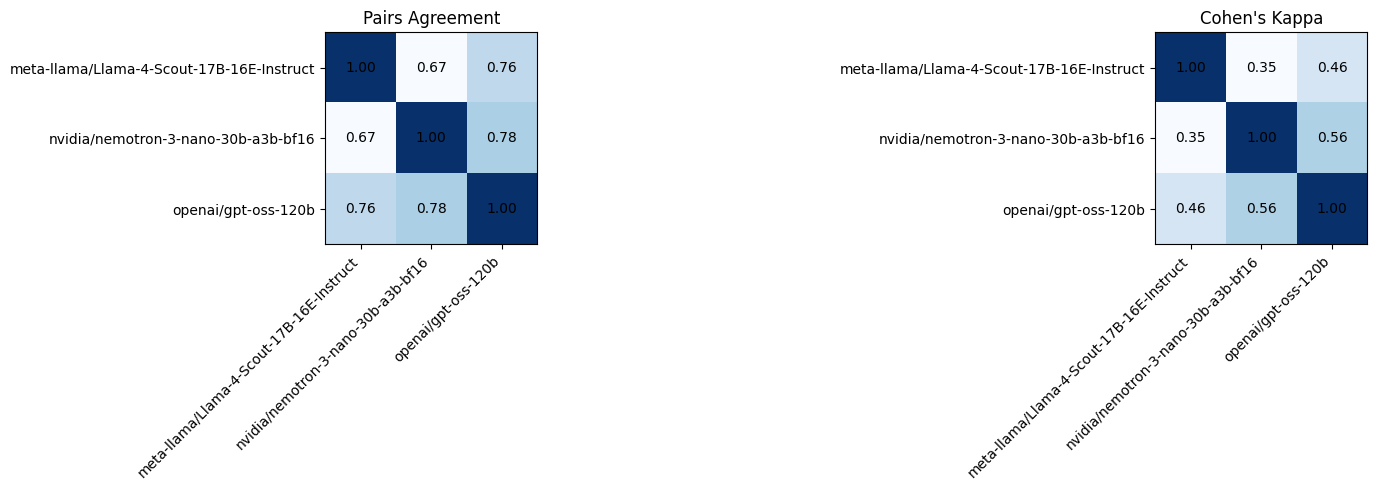

In [169]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

matrices = [
    (agreement_matrix, "Pairs Agreement", "{:.2f}"),
    (kappa_matrix, "Cohen's Kappa", "{:.2f}"),
]

for ax, (matrix, title, fmt) in zip(axes, matrices):
    data = matrix.astype(float).values

    im = ax.imshow(data, cmap="Blues")

    # labels
    ax.set_xticks(range(len(matrix.columns)))
    ax.set_yticks(range(len(matrix.index)))
    ax.set_xticklabels(matrix.columns, rotation=45, ha="right")
    ax.set_yticklabels(matrix.index)

    # numbers inside cells
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            ax.text(j, i, fmt.format(data[i, j]),
                    ha="center", va="center")

    ax.set_title(title)

plt.tight_layout()
plt.show()

In [170]:
print(f"Total agreement across all annotators: {total_agreement:.2f}%")

Total agreement across all annotators: 59.98%
